In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
import warnings
warnings.filterwarnings("ignore")

In [13]:
df = pd.read_csv("Bank Customer Churn Prediction.csv")

In [14]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [16]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [17]:
df.shape

(10000, 12)

In [18]:
df["churn"].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [20]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [21]:
sns.set_theme(style = 'whitegrid')


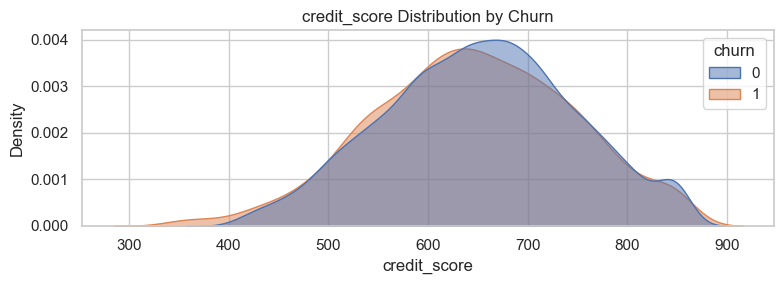

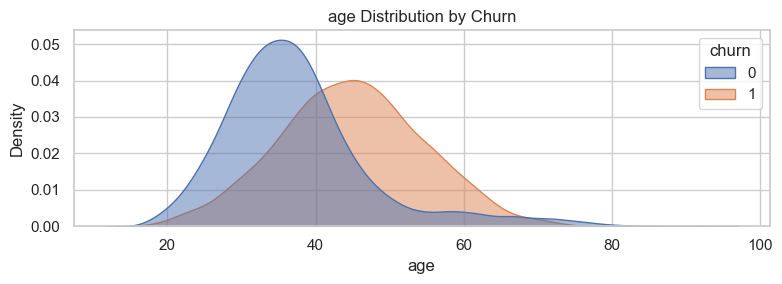

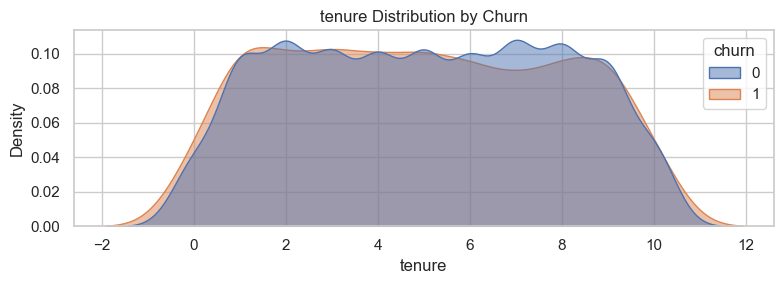

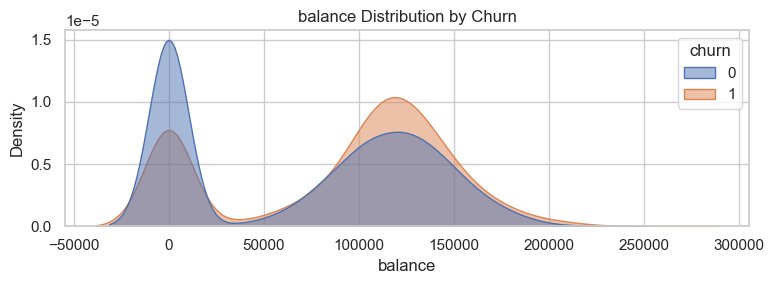

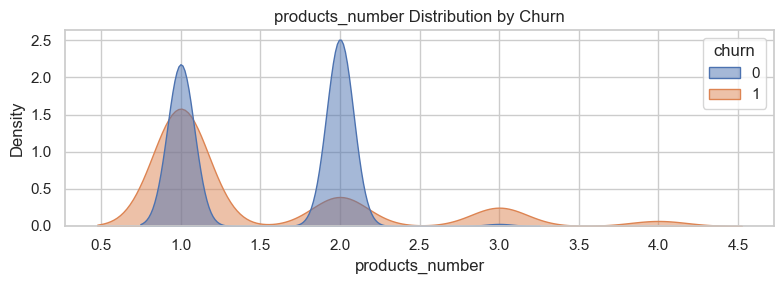

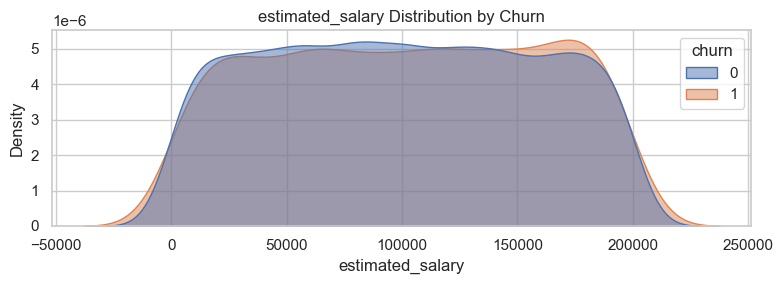

In [32]:
# Distribution plots
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.kdeplot(data=df, x=col, hue='churn', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'{col} Distribution by Churn')
    plt.tight_layout()
    plt.show()

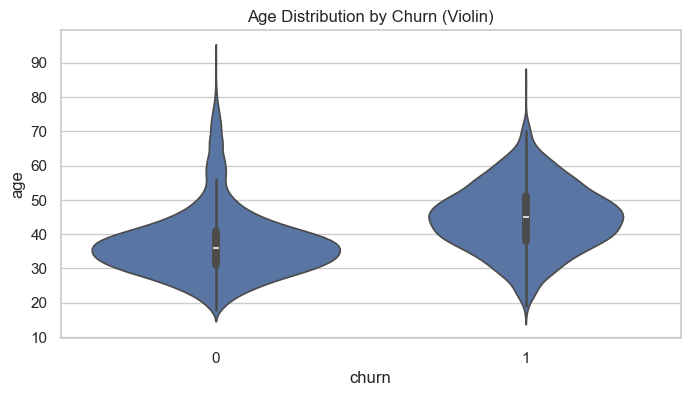

In [24]:
# Violin Plot for Ages
plt.figure(figsize = (8,4))
sns.violinplot(data = df, x = "churn", y = "age")
plt.title('Age Distribution by Churn (Violin)')
plt.show()

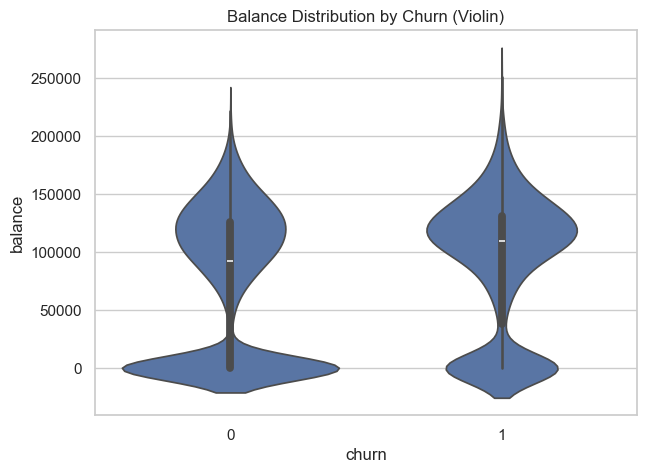

In [25]:
plt.figure(figsize=(7,5))
sns.violinplot(x='churn', y='balance', data=df)
plt.title('Balance Distribution by Churn (Violin)')
plt.show()

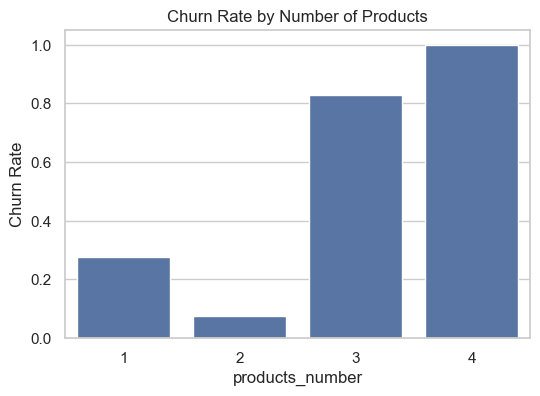

In [26]:
# Churn by no of products
plt.figure(figsize=(6,4))
sns.barplot(x='products_number', y='churn', data=df, errorbar=None)
plt.title('Churn Rate by Number of Products')
plt.ylabel('Churn Rate')
plt.show()

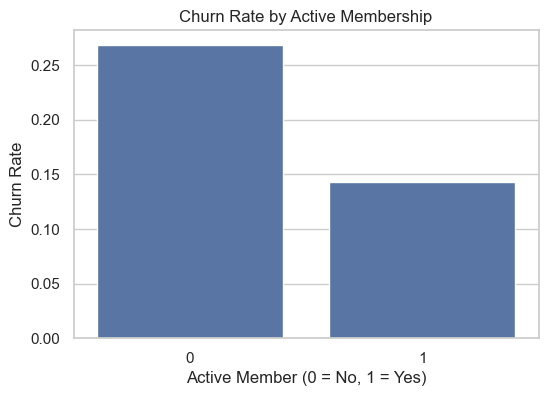

In [27]:
# Churn by active membership
plt.figure(figsize=(6,4))
sns.barplot(x='active_member', y='churn', data=df, errorbar=None)
plt.title('Churn Rate by Active Membership')
plt.xlabel('Active Member (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate')
plt.show()

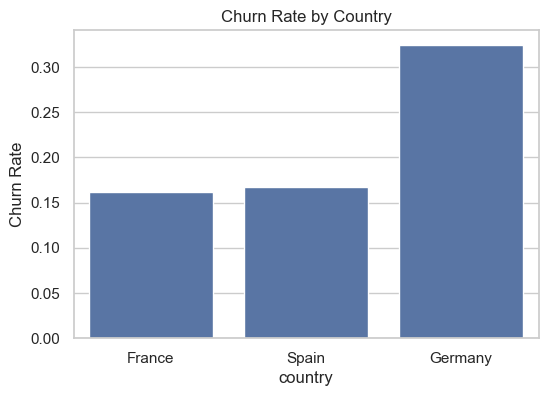

In [28]:
# Churn by country
plt.figure(figsize=(6,4))
sns.barplot(x='country', y='churn', data=df, errorbar=None)
plt.title('Churn Rate by Country')
plt.ylabel('Churn Rate')
plt.show()

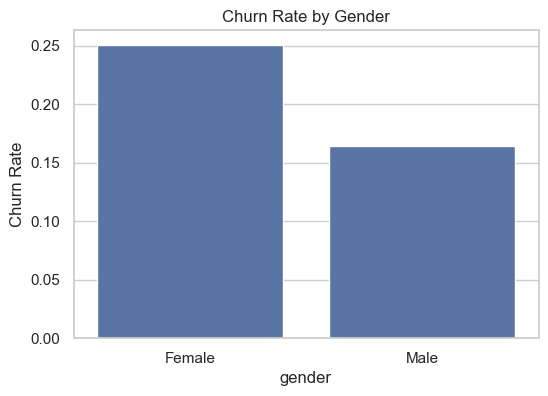

In [30]:
# Gender vs churn
plt.figure(figsize=(6,4))
sns.barplot(x='gender', y='churn', data=df, errorbar=None)
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate')
plt.show()

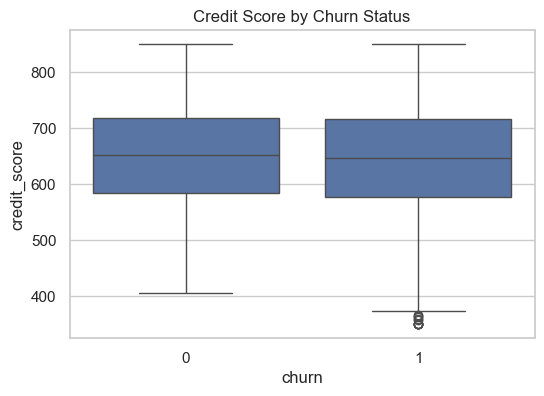

In [29]:
# Credit-score vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='credit_score', data=df)
plt.title('Credit Score by Churn Status')
plt.show()


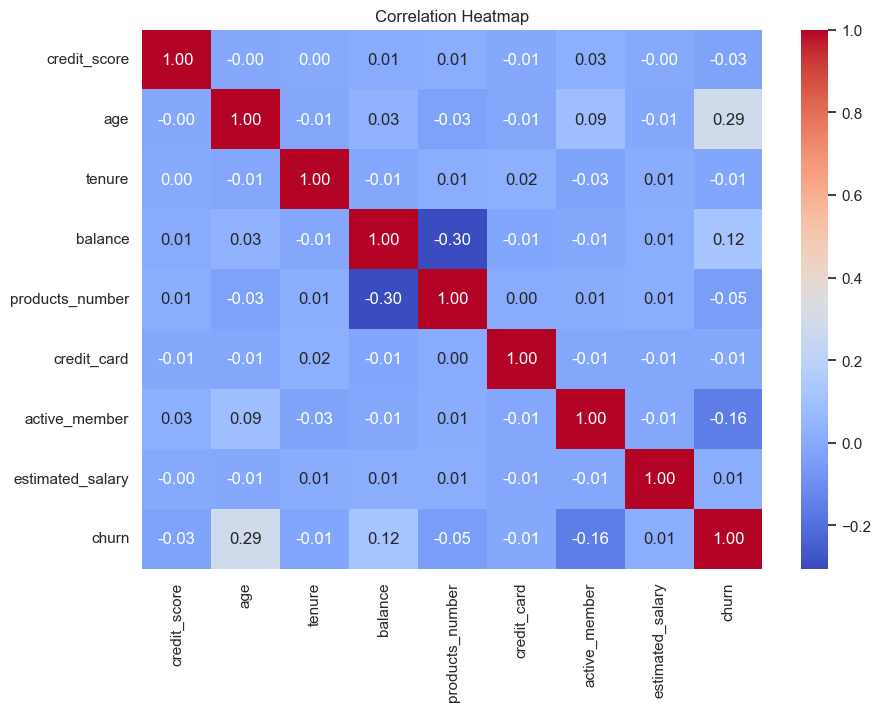

In [31]:
# Correlation heatmap (numeric columns only)
plt.figure(figsize=(10,7))
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['customer_id'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [33]:
# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics & utilities
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


# Feature Engineering

In [34]:
df_model = df.copy()

In [35]:
# Feature engineering examples

# Balance per product
df_model['balance_per_product'] = df_model['balance'] / (
    df_model['products_number'].replace(0, np.nan)
)
df_model['balance_per_product'].fillna(0, inplace=True)

# Salary to balance ratio
df_model['salary_balance_ratio'] = df_model['estimated_salary'] / (
    df_model['balance'].replace(0, np.nan)
)
df_model['salary_balance_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
df_model['salary_balance_ratio'].fillna(
    df_model['salary_balance_ratio'].median(), inplace=True
)

In [37]:
# Feature engineering examples

# Age group
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df_model['age_group'] = pd.cut(
    df_model['age'], bins=bins, labels=labels
)

# Tenure bucket
df_model['tenure_bucket'] = pd.cut(
    df_model['tenure'],
    bins=[-1, 0, 2, 5, 10, 100],
    labels=['0', '1-2', '3-5', '6-10', '10+']
)

# Flag high balance
df_model['high_balance'] = (
    df_model['balance'] > df_model['balance'].quantile(0.75)
).astype(int)


In [39]:
# Quick checks
df_model[
    [
        'balance_per_product',
        'salary_balance_ratio',
        'age',
        'age_group',
        'tenure',
        'tenure_bucket',
        'high_balance'
    ]
].head()

,balance_per_product,salary_balance_ratio,age,age_group,tenure,tenure_bucket,high_balance
0,0.000000,0.839258,42,35-44,2,1-2,0
1,83807.860000,1.342864,41,35-44,1,1-2,0
2,53220.266667,0.713585,42,35-44,8,6-10,1
3,0.000000,0.839258,39,35-44,1,1-2,0
4,125510.820000,0.630098,43,35-44,2,1-2,0


In [40]:
# Define features and target
target = 'churn'
drop_cols = ['customer_id']

features = [c for c in df_model.columns if c not in [target] + drop_cols]

numeric_features = [
    'credit_score',
    'age',
    'tenure',
    'balance',
    'products_number',
    'estimated_salary',
    'balance_per_product',
    'salary_balance_ratio'
]

categorical_features = [
    'country',
    'gender',
    'credit_card',
    'active_member',
    'age_group',
    'tenure_bucket',
    'high_balance'
]

In [41]:
df_model[categorical_features] = df_model[categorical_features].astype('object')

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'balance_per_product', 'salary_balance_ratio']
Categorical features: ['country', 'gender', 'credit_card', 'active_member', 'age_group', 'tenure_bucket', 'high_balance']


# Training and Evaluate

In [42]:
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, stratify = y, random_state = 42)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train churn proportion:", y_train.mean(),
      "Test churn proportion:", y_test.mean())

Train shape: (8000, 15) Test shape: (2000, 15)
Train churn proportion: 0.20375 Test churn proportion: 0.2035


In [46]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=500),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        random_state=42
    ),
    "SVC": SVC(
        probability=True,
        random_state=42
    )
}


In [47]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
results = {}

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    results[name] = scores

In [48]:
for name, scores in results.items():

    print(
        f"{name} AUC: "
        f"Mean={scores.mean():.4f} "
        f"Std={scores.std():.4f}"
    )

LogisticRegression AUC: Mean=0.7877 Std=0.0244
RandomForest AUC: Mean=0.8494 Std=0.0131
GradientBoosting AUC: Mean=0.8629 Std=0.0098
AdaBoost AUC: Mean=0.8462 Std=0.0133
SVC AUC: Mean=0.8351 Std=0.0104


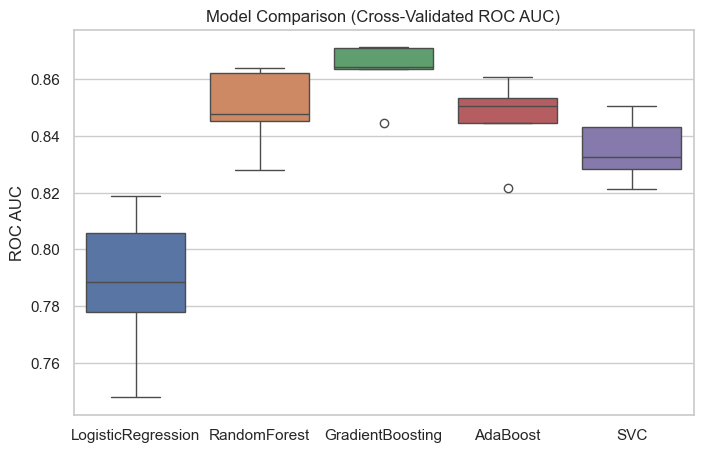

In [49]:
# Boxplot of CV AUC scores
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=[results[m] for m in list(results.keys())]
)

plt.xticks(
    ticks=range(len(results)),
    labels=list(results.keys())
)

plt.ylabel("ROC AUC")
plt.title("Model Comparison (Cross-Validated ROC AUC)")
plt.show()

# Fit the best model on the full training set and evaluate on test set
select the best model on Mean AUC above and evaluate standard metric on the test set


In [50]:
# Choose best model (automatic pick by mean AUC)
best_name = max(results.keys(), key=lambda k: results[k].mean())
best_name, results[best_name].mean()

('GradientBoosting', np.float64(0.8628870472209649))

In [51]:
best_model = models[best_name]

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", best_model)
])

best_pipeline.fit(X_train, y_train)

# Predictions
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

In [53]:
# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test F1-score: {f1:.4f}")
print(f"Test ROC AUC: {roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8680
Test Precision: 0.7804
Test Recall: 0.4889
Test F1-score: 0.6012
Test ROC AUC: 0.8692

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



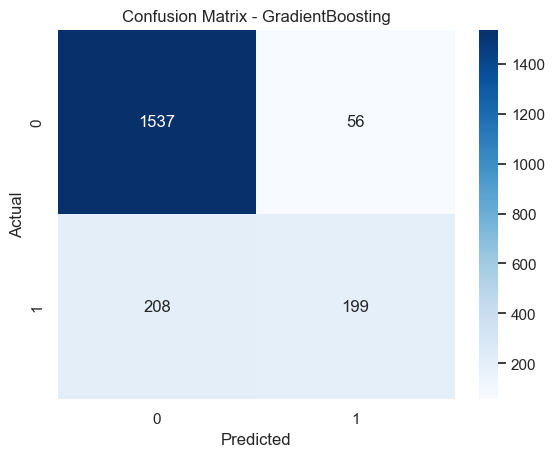

In [54]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

age                     0.327798
products_number         0.266458
balance_per_product     0.063208
balance                 0.056882
active_member_0         0.052799
country_Germany         0.050689
active_member_1         0.047847
salary_balance_ratio    0.030023
estimated_salary        0.025510
credit_score            0.022685
age_group_45-54         0.020634
age_group_55-64         0.007968
gender_Female           0.007420
gender_Male             0.005962
tenure                  0.005683
country_France          0.003164
tenure_bucket_3-5       0.001564
age_group_35-44         0.001415
credit_card_1           0.000697
country_Spain           0.000577
dtype: float64

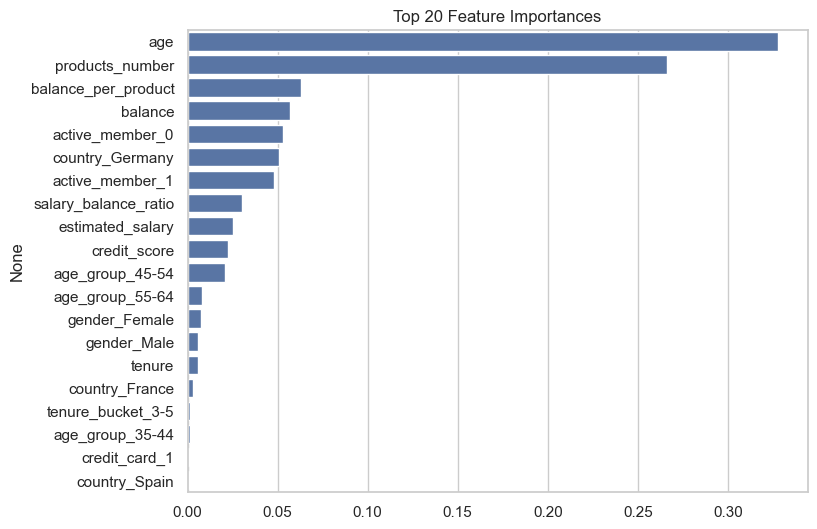

In [55]:
# Feature importance (if applicable)

# If the chosen model supports feature importance
# (RandomForest / GradientBoosting), show top features

if hasattr(best_pipeline.named_steps["classifier"], "feature_importances_"):

    num_feats = numeric_features

    cat_feats = list(
        best_pipeline.named_steps["preprocessor"]
        .transformers_[1][1]
        .named_steps["onehot"]
        .get_feature_names_out(categorical_features)
    )

    feature_names = num_feats + cat_feats

    importances = best_pipeline.named_steps[
        "classifier"
    ].feature_importances_

    fi = pd.Series(
        importances,
        index=feature_names
    ).sort_values(ascending=False)[:20]

    display(fi)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=fi.values, y=fi.index)
    plt.title("Top 20 Feature Importances")
    plt.show()

else:
    print(
        "Selected model does not provide feature_importances_ attribute."
    )

In [57]:
# Save the best pipeline and preprocessing artifacts
import joblib
joblib.dump(best_pipeline, "best_churn_pipeline.pkl")
print("Saved pipeline: best_churn_pipeline.pkl")

Saved pipeline: best_churn_pipeline.pkl
